# Kafka Prediction Consumers and Visualisations

This notebook consumes the prediction topics produced by the Spark streaming pipeline and renders live visual summaries for building-level, site-level, and prediction-vs-meter comparisons.

In [1]:
import json, time, threading, queue
from collections import OrderedDict
import pandas as pd
import matplotlib.pyplot as plt
from kafka3 import KafkaConsumer
from matplotlib.animation import FuncAnimation
from matplotlib.dates import AutoDateLocator, ConciseDateFormatter
from matplotlib.ticker import FuncFormatter, MaxNLocator
from datetime import timedelta

# Needed for interactive plots
%matplotlib widget

# Parameters
KAFKA_SERVERS = "kafka:9092"
RUN_ID = pd.Timestamp.utcnow().strftime("%Y%m%d%H%M%S")
CONSUMER_OFFSET_RESET = "latest"  # Use "earliest" only when replaying old Kafka output intentionally.
MAX_RECORDS_PER_POLL = 500
MAX_BUILDING_RECORDS = 20000
MAX_SITE_RECORDS = 5000

BUILDING_GROUP_ID = f"task3_building_{RUN_ID}"
SITE_GROUP_ID = f"task3_site_{RUN_ID}"

# Fresh group IDs avoid resuming stale committed offsets from previous notebook runs.
consumer_building = KafkaConsumer(
    'agg_building6h_7b',
    bootstrap_servers=KAFKA_SERVERS,
    auto_offset_reset=CONSUMER_OFFSET_RESET,
    group_id=BUILDING_GROUP_ID,
    value_deserializer=lambda v: json.loads(v.decode('utf-8'))
)

consumer_site = KafkaConsumer(
    'agg_site_daily_7c',
    bootstrap_servers=KAFKA_SERVERS,
    auto_offset_reset=CONSUMER_OFFSET_RESET,
    group_id=SITE_GROUP_ID,
    value_deserializer=lambda v: json.loads(v.decode('utf-8'))
)

print(f"Building consumer group: {BUILDING_GROUP_ID}")
print(f"Site consumer group: {SITE_GROUP_ID}")
print(f"Offset reset mode: {CONSUMER_OFFSET_RESET}")

Building consumer group: task3_building_20260624131038
Site consumer group: task3_site_20260624131038
Offset reset mode: latest


## Meter Data for Comparison

In [2]:
# Read metered data for comparison
meters = pd.read_csv("new_meters.csv", parse_dates=["ts"])
buildings = pd.read_csv("new_building_information.csv")

meters["building_id"] = meters["building_id"].astype(str)
buildings["building_id"] = buildings["building_id"].astype(str)
buildings["site_id"] = buildings["site_id"].astype(str)

meters["date"] = pd.to_datetime(meters["ts"].dt.date)
site_map = buildings[["building_id", "site_id"]].drop_duplicates()
meters = meters.merge(site_map, on="building_id", how="left")

# Expected complete daily prediction rows: one 6-hour block per building, four blocks per day.
SITE_BUILDING_COUNTS = buildings.groupby("site_id")["building_id"].nunique().to_dict()
SITE_EXPECTED_DAILY_BLOCKS = {site_id: count * 4 for site_id, count in SITE_BUILDING_COUNTS.items()}

# Prepare for visualisation later.
daily_meter = (
    meters.groupby(["date", "site_id"], as_index=False)
    .agg(metered_total=("value", "sum"))
)

In [3]:
daily_meter

,date,site_id,metered_total
0,2022-01-01,0,138.7303
1,2022-01-01,1,61145.2214
2,2022-01-01,10,143622.1546
3,2022-01-01,11,10294.1020
4,2022-01-01,12,23290.6900
...,...,...,...
5776,2022-12-31,5,17149.6240
5777,2022-12-31,6,279892.2386
5778,2022-12-31,7,338965.8900
5779,2022-12-31,8,1733.0016


## Live Prediction Visualisations

**Plot execution note**

Run Task 2 section 2.8 first so the Parquet outputs are being republished to Kafka. These consumers use fresh group IDs for each notebook run and keep bounded, deduplicated in-memory state keyed by `record_key`, so counters in the plot titles should rise only when new Kafka records arrive.

### Plot 1: Six-Hour Building Energy Predictions

This plot consumes the building-level prediction topic and shows:

- the currently streamed site
- the top 5 buildings by predicted energy in the active window
- a 30-day rolling view of predicted 6-hour energy consumption per building

In [4]:
# Shared bounded state and plotting helpers for interactive plots

def make_record_state(max_records, label):
    return {
        "label": label,
        "lock": threading.Lock(),
        "records": OrderedDict(),
        "received": 0,
        "last_update": None,
        "latest_event_time": None,
        "latest_site_id": None,
        "stop_event": threading.Event(),
        "max_records": max_records,
    }


def _record_key(rec, fallback_label):
    key = rec.get("record_key")
    if key:
        return str(key)
    return "|".join(str(rec.get(col, "")) for col in [fallback_label, "site_id", "building_id", "date", "hour_block", "wdw_start"])


def upsert_records(state, batch_records, event_col="wdw_start"):
    if not batch_records:
        return

    latest_event = None
    latest_site_id = None
    for rec in batch_records:
        event_value = pd.to_datetime(rec.get(event_col), errors="coerce", utc=True)
        if pd.notna(event_value) and (latest_event is None or event_value > latest_event):
            latest_event = event_value
        if rec.get("site_id") is not None:
            latest_site_id = rec.get("site_id")

    with state["lock"]:
        for rec in batch_records:
            key = _record_key(rec, state["label"])
            if key in state["records"]:
                del state["records"][key]
            state["records"][key] = rec
            while len(state["records"]) > state["max_records"]:
                state["records"].popitem(last=False)

        state["received"] += len(batch_records)
        state["last_update"] = pd.Timestamp.utcnow()
        if latest_event is not None:
            state["latest_event_time"] = latest_event
        if latest_site_id is not None:
            state["latest_site_id"] = latest_site_id


def snapshot_state(state):
    with state["lock"]:
        records = list(state["records"].values())
        meta = {
            "stored": len(records),
            "received": state["received"],
            "last_update": state["last_update"],
            "latest_event_time": state["latest_event_time"],
            "latest_site_id": state["latest_site_id"],
        }
    return records, meta


def _fmt_ts(value):
    if value is None or pd.isna(value):
        return "none"
    return pd.to_datetime(value).strftime("%Y-%m-%d %H:%M:%S")


def _state_suffix(meta):
    return f"stored={meta['stored']} received={meta['received']} latest_event={_fmt_ts(meta['latest_event_time'])} updated={_fmt_ts(meta['last_update'])}"


def _status_text(meta, extra=None):
    parts = [
        f"stored {meta['stored']:,}",
        f"received {meta['received']:,}",
        f"latest event {_fmt_ts(meta['latest_event_time'])}",
        f"updated {_fmt_ts(meta['last_update'])}",
    ]
    if extra:
        parts.append(extra)
    return " | ".join(parts)


def _format_energy(value, pos=None):
    if pd.isna(value):
        return ""
    abs_value = abs(value)
    if abs_value >= 1_000_000:
        return f"{value / 1_000_000:.1f}M"
    if abs_value >= 1_000:
        return f"{value / 1_000:.0f}k"
    return f"{value:.0f}"


def _decorate_live_axes(ax, title, ylabel, status=None, zero_line=False, legend=True):
    ax.set_title(title, fontsize=12, pad=14)
    ax.set_xlabel("Date")
    ax.set_ylabel(ylabel)

    locator = AutoDateLocator(minticks=3, maxticks=6)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(ConciseDateFormatter(locator))
    ax.yaxis.set_major_formatter(FuncFormatter(_format_energy))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=7))
    ax.grid(True, axis="y", alpha=0.25)

    if zero_line:
        ax.axhline(0, color="#333333", linewidth=1, alpha=0.7)

    if status:
        ax.text(
            0.01,
            0.98,
            status,
            ha="left",
            va="top",
            transform=ax.transAxes,
            fontsize=8,
            color="#444444",
            bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": "#cccccc", "alpha": 0.86},
        )

    if legend:
        handles, labels = ax.get_legend_handles_labels()
        if labels:
            ax.legend(frameon=False, loc="best", fontsize=9)

    ax.relim()
    ax.autoscale_view()


def _show_empty_plot(ax, title, message, meta=None, ylabel="Energy"):
    status = _status_text(meta) if meta else None
    ax.text(0.5, 0.5, message, ha="center", va="center", transform=ax.transAxes, color="#555555")
    _decorate_live_axes(ax, title, ylabel, status=status, legend=False)
    return ax


def _configure_live_figure(fig):
    fig.subplots_adjust(left=0.12, right=0.97, bottom=0.18, top=0.88)


BUILDING_STATE = make_record_state(MAX_BUILDING_RECORDS, "building")

In [5]:
# Consumer thread for building prediction records

def consume_building(consumer, state):
    while not state["stop_event"].is_set():
        msg_pack = consumer.poll(timeout_ms=1000, max_records=MAX_RECORDS_PER_POLL)
        batch = []
        for tp, messages in (msg_pack or {}).items():
            for msg in messages:
                rec = dict(msg.value)
                rec["wdw_start"] = pd.to_datetime(rec.get("wdw_start"), errors="coerce", utc=True)
                rec["wdw_end"] = pd.to_datetime(rec.get("wdw_end"), errors="coerce", utc=True)
                batch.append(rec)

        if batch:
            upsert_records(state, batch, event_col="wdw_start")
        else:
            time.sleep(0.2)

In [6]:
WINDOW = pd.Timedelta(days=30)


def update_building_ax(frame, ax):
    ax.clear()
    data, meta = snapshot_state(BUILDING_STATE)
    title = "Top Building Predictions by 6-Hour Block"
    ylabel = "Predicted Energy (6h)"

    if not data:
        return _show_empty_plot(ax, title, "Waiting for building prediction records...", meta, ylabel)

    df = pd.DataFrame(data)
    need = {"building_id", "wdw_start", "site_id", "energy_consumption_6h"}
    if not need.issubset(df.columns):
        missing = ", ".join(sorted(need - set(df.columns)))
        return _show_empty_plot(ax, title, f"Missing columns: {missing}", meta, ylabel)

    if "record_key" in df.columns:
        df = df.drop_duplicates(subset=["record_key"], keep="last")

    df["wdw_start"] = pd.to_datetime(df["wdw_start"], errors="coerce", utc=True).dt.tz_localize(None)
    df["energy_consumption_6h"] = pd.to_numeric(df["energy_consumption_6h"], errors="coerce")
    df["building_id"] = df["building_id"].astype(str)
    df["site_id"] = df["site_id"].astype(str)
    df = df.dropna(subset=["wdw_start", "energy_consumption_6h"])

    if df.empty:
        return _show_empty_plot(ax, title, "No valid building prediction points yet", meta, ylabel)

    current_site = str(meta.get("latest_site_id")) if meta.get("latest_site_id") is not None else df.sort_values("wdw_start")["site_id"].iloc[-1]
    site_df = df[df["site_id"] == current_site]
    if site_df.empty:
        site_df = df

    cutoff = site_df["wdw_start"].max() - WINDOW
    site_df = site_df[site_df["wdw_start"] >= cutoff]

    top_ids = (site_df.groupby("building_id")["energy_consumption_6h"]
                 .sum().sort_values(ascending=False).head(5).index)

    if len(top_ids) == 0:
        return _show_empty_plot(ax, title, "No buildings available for the selected site", meta, ylabel)

    for bid, g in site_df[site_df["building_id"].isin(top_ids)].sort_values(["building_id", "wdw_start"]).groupby("building_id"):
        ax.plot(g["wdw_start"], g["energy_consumption_6h"], label=f"Building {bid}", linewidth=1.8)

    status = _status_text(meta, f"site {current_site} | plotted points {len(site_df):,}")
    _decorate_live_axes(ax, title, ylabel, status=status)
    return ax

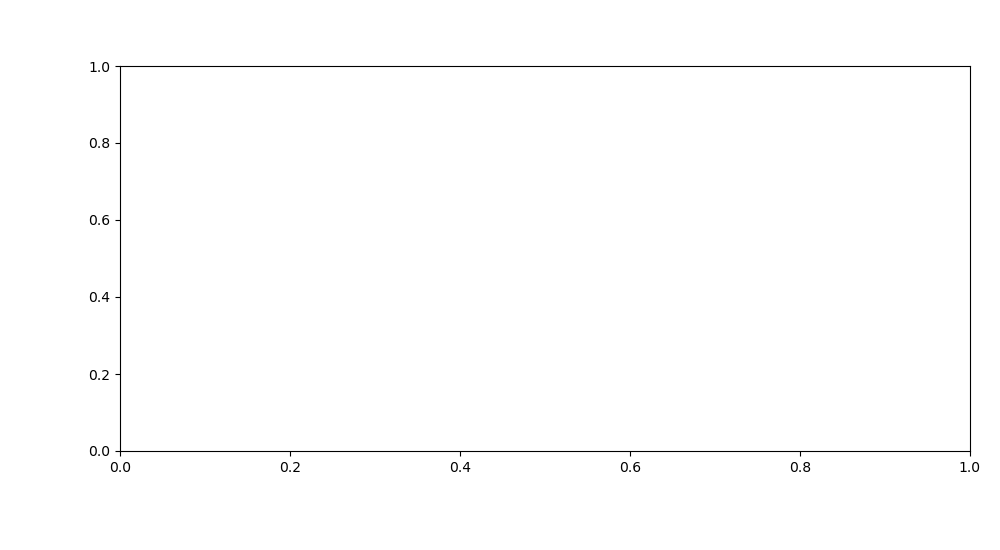

In [23]:
# Start background Kafka consumer

def ensure_building_consumer():
    global BUILDING_STATE, t_build
    if BUILDING_STATE["stop_event"].is_set():
        BUILDING_STATE = make_record_state(MAX_BUILDING_RECORDS, "building")
    if "t_build" not in globals() or not t_build.is_alive():
        t_build = threading.Thread(target=consume_building, args=(consumer_building, BUILDING_STATE), daemon=True)
        t_build.start()
    return t_build


ensure_building_consumer()

# Create the live figure
fig_build, ax_build = plt.subplots(figsize=(10, 5.5))
_configure_live_figure(fig_build)

ani_build = FuncAnimation(
    fig_build,
    update_building_ax,
    fargs=(ax_build,),
    interval=2000,
    cache_frame_data=False
)

In [24]:
#SHUTDOWN GRAPH 1 - RUN THIS BEFORE GOING FORWARD AFTER HAVING SEEN ENOUGH OF GRAPH
BUILDING_STATE["stop_event"].set()
if "t_build" in globals():
    t_build.join(timeout=2)
if "ani_build" in globals():
    ani_build.event_source.stop()
print("Stopped building stream plot.")

SyntaxError: invalid syntax (75368998.py, line 7)

### Plot 2: Daily Site Energy Predictions

This plot consumes the site-level daily prediction topic and shows a daily energy time series per site:

- each line represents one site
- the y-axis shows predicted total daily energy consumption for the whole site

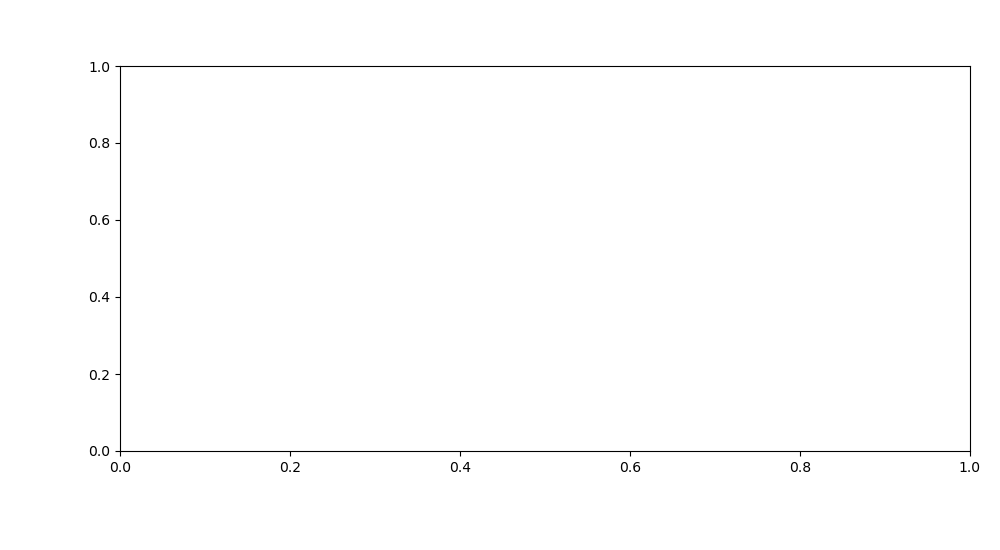

In [19]:
if "SITE_STATE" not in globals() or SITE_STATE["stop_event"].is_set():
    SITE_STATE = make_record_state(MAX_SITE_RECORDS, "site")


def consume_site(consumer, state):
    while not state["stop_event"].is_set():
        msg_pack = consumer.poll(timeout_ms=1000, max_records=MAX_RECORDS_PER_POLL)
        batch = []
        for tp, messages in (msg_pack or {}).items():
            for msg in messages:
                rec = dict(msg.value)
                rec["wdw_start"] = pd.to_datetime(rec.get("wdw_start"), errors="coerce", utc=True)
                rec["wdw_end"] = pd.to_datetime(rec.get("wdw_end"), errors="coerce", utc=True)
                batch.append(rec)

        if batch:
            upsert_records(state, batch, event_col="wdw_start")
        else:
            time.sleep(0.2)


def ensure_site_consumer():
    global SITE_STATE, t_site
    if SITE_STATE["stop_event"].is_set():
        SITE_STATE = make_record_state(MAX_SITE_RECORDS, "site")
    if "t_site" not in globals() or not t_site.is_alive():
        t_site = threading.Thread(target=consume_site, args=(consumer_site, SITE_STATE), daemon=True)
        t_site.start()
    return t_site


def update_site_ax(frame, ax):
    ax.clear()
    data, meta = snapshot_state(SITE_STATE)
    title = "Daily Predicted Energy by Site"
    ylabel = "Predicted Daily Energy"

    if not data:
        return _show_empty_plot(ax, title, "Waiting for site prediction records...", meta, ylabel)

    df = pd.DataFrame(data)
    needed = {"site_id", "wdw_start", "daily_consumption_site"}
    if not needed.issubset(df.columns):
        missing = ", ".join(sorted(needed - set(df.columns)))
        return _show_empty_plot(ax, title, f"Missing columns: {missing}", meta, ylabel)

    if "record_key" in df.columns:
        df = df.drop_duplicates(subset=["record_key"], keep="last")

    df["wdw_start"] = pd.to_datetime(df["wdw_start"], errors="coerce", utc=True).dt.tz_localize(None)
    df["daily_consumption_site"] = pd.to_numeric(df["daily_consumption_site"], errors="coerce")
    df["site_id"] = df["site_id"].astype(str)
    df = df.dropna(subset=["wdw_start", "daily_consumption_site"])
    if df.empty:
        return _show_empty_plot(ax, title, "No valid site prediction points yet", meta, ylabel)

    df["date"] = pd.to_datetime(df["wdw_start"].dt.date)
    df = df.sort_values(["site_id", "date"])

    for sid, g in df.groupby("site_id"):
        ax.plot(g["date"].values, g["daily_consumption_site"].values, label=f"Site {sid}", linewidth=1.8)

    site_days = df[["site_id", "date"]].drop_duplicates().shape[0]
    status = _status_text(meta, f"sites {df['site_id'].nunique()} | site-days {site_days:,}")
    _decorate_live_axes(ax, title, ylabel, status=status)
    return ax


ensure_site_consumer()

fig_site, ax_site = plt.subplots(figsize=(10, 5.5))
_configure_live_figure(fig_site)

ani_site = FuncAnimation(
    fig_site,
    update_site_ax,
    fargs=(ax_site,),
    interval=2000,
    cache_frame_data=False
)

In [20]:
#SHUTDOWN GRAPH 2 - RUN THIS BEFORE GOING FORWARD AFTER HAVING SEEN ENOUGH OF GRAPH
SITE_STATE["stop_event"].set()
if "t_site" in globals():
    t_site.join(timeout=2)
if "ani_site" in globals():
    ani_site.event_source.stop()
print("Stopped site stream plot and shared site consumer.")

Stopped site stream plot and shared site consumer.


## Daily Prediction Shortfall and Excess

### Plot 3: Prediction vs Metered Energy by Site

In [ ]:
def _to_nullable_bool(value):
    if pd.isna(value):
        return pd.NA
    if isinstance(value, bool):
        return value
    text = str(value).strip().lower()
    if text in {"true", "1", "yes", "y"}:
        return True
    if text in {"false", "0", "no", "n"}:
        return False
    return pd.NA


def prepare_site_prediction_frame(records):
    df = pd.DataFrame(records)
    if df.empty:
        return df

    required = {"site_id", "wdw_start", "daily_consumption_site"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {', '.join(sorted(missing))}")

    df["wdw_start"] = pd.to_datetime(df["wdw_start"], errors="coerce", utc=True).dt.tz_localize(None)
    df["site_id"] = df["site_id"].astype(str)
    if "date" in df.columns:
        payload_date = pd.to_datetime(df["date"], errors="coerce").dt.normalize()
        df["date"] = payload_date.fillna(df["wdw_start"].dt.normalize())
    else:
        df["date"] = df["wdw_start"].dt.normalize()
    df["daily_consumption_site"] = pd.to_numeric(df["daily_consumption_site"], errors="coerce")

    if "building_block_count" not in df.columns:
        df["building_block_count"] = pd.NA
    df["building_block_count"] = pd.to_numeric(df["building_block_count"], errors="coerce")

    if "hour_block_count" not in df.columns:
        df["hour_block_count"] = pd.NA
    df["hour_block_count"] = pd.to_numeric(df["hour_block_count"], errors="coerce")

    mapped_expected = pd.to_numeric(df["site_id"].map(SITE_EXPECTED_DAILY_BLOCKS), errors="coerce")
    if "expected_block_count" in df.columns:
        df["expected_block_count"] = pd.to_numeric(df["expected_block_count"], errors="coerce").fillna(mapped_expected)
    else:
        df["expected_block_count"] = mapped_expected

    fallback_complete = (
        df["building_block_count"].notna()
        & df["expected_block_count"].notna()
        & (df["building_block_count"] >= df["expected_block_count"])
        & (df["hour_block_count"].isna() | (df["hour_block_count"] >= 4))
    )

    if "is_complete_day" in df.columns:
        emitted_complete = df["is_complete_day"].map(_to_nullable_bool).astype("boolean")
        df["is_complete_day"] = emitted_complete.fillna(fallback_complete).astype(bool)
    else:
        df["is_complete_day"] = fallback_complete.astype(bool)

    df = df.dropna(subset=["date", "site_id", "daily_consumption_site"])
    df["_sort_hour_blocks"] = df["hour_block_count"].fillna(-1)
    df["_sort_blocks"] = df["building_block_count"].fillna(-1)
    df = df.sort_values(["site_id", "date", "_sort_hour_blocks", "_sort_blocks", "wdw_start"])

    if "record_key" in df.columns:
        df = df.drop_duplicates(subset=["record_key"], keep="last")
    else:
        df = df.drop_duplicates(subset=["site_id", "date"], keep="last")

    return df.drop(columns=["_sort_hour_blocks", "_sort_blocks"], errors="ignore")


def build_prediction_error_frame(records, daily_meter_df, complete_only=True):
    pred = prepare_site_prediction_frame(records)
    if pred.empty:
        return pred, pred

    meter = daily_meter_df.copy()
    meter["date"] = pd.to_datetime(meter["date"], errors="coerce").dt.normalize()
    meter["site_id"] = meter["site_id"].astype(str)
    meter["metered_total"] = pd.to_numeric(meter["metered_total"], errors="coerce")
    meter = meter.dropna(subset=["date", "site_id", "metered_total"])

    joined = pred.merge(meter, on=["site_id", "date"], how="inner")
    if complete_only:
        joined = joined[joined["is_complete_day"]].copy()
    else:
        joined = joined.copy()

    if not joined.empty:
        joined["prediction_error"] = joined["daily_consumption_site"] - joined["metered_total"]

    return joined, pred


def _read_manifest_backed_site_predictions(base_path="parquet/a2b"):
    import os, json
    manifest_path = os.path.join(base_path, "_manifest", "current.json")
    if not os.path.exists(manifest_path):
        raise FileNotFoundError(manifest_path)
    with open(manifest_path, "r", encoding="utf-8") as f:
        manifest = json.load(f)
    table_paths = manifest.get("tables", {}).get("7c_site_daily", {})
    paths = [p for p in table_paths.values() if os.path.exists(p)]
    if not paths:
        return pd.DataFrame()
    frames = [pd.read_parquet(p) for p in sorted(set(paths))]
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def _read_site_prediction_parquet(parquet_path="parquet/a2b/7c_site_daily"):
    try:
        return pd.read_parquet(parquet_path)
    except Exception:
        base_path = parquet_path.replace("/7c_site_daily", "").replace("\\7c_site_daily", "")
        try:
            return _read_manifest_backed_site_predictions(base_path=base_path)
        except Exception:
            import pyarrow.dataset as ds
            return ds.dataset(parquet_path, format="parquet").to_table().to_pandas()


def diagnose_site_prediction_errors(records=None, source="live", parquet_path="parquet/a2b/7c_site_daily"):
    if records is None and source == "parquet":
        try:
            records = _read_site_prediction_parquet(parquet_path).to_dict("records")
        except Exception as exc:
            print(f"Could not read site prediction Parquet at {parquet_path}: {type(exc).__name__}: {exc}")
            return pd.DataFrame()
    elif records is None:
        records, _ = snapshot_state(SITE_STATE)

    joined, pred = build_prediction_error_frame(records, daily_meter, complete_only=False)
    if pred.empty:
        print("No site prediction records available for diagnostics.")
        return joined

    coverage = (
        pred.groupby("site_id", as_index=False)
            .agg(
                prediction_days=("date", "nunique"),
                received_records=("date", "size"),
                complete_days=("is_complete_day", "sum"),
                avg_prediction=("daily_consumption_site", "mean"),
                avg_block_count=("building_block_count", "mean"),
                avg_hour_block_count=("hour_block_count", "mean"),
                expected_block_count=("expected_block_count", "max"),
            )
    )
    coverage["partial_days"] = coverage["prediction_days"] - coverage["complete_days"]

    if joined.empty:
        display(coverage)
        return joined

    complete_joined = joined[joined["is_complete_day"]].copy()
    error_summary = (
        complete_joined.groupby("site_id", as_index=False)
            .agg(
                joined_complete_days=("date", "nunique"),
                avg_metered=("metered_total", "mean"),
                avg_error=("prediction_error", "mean"),
                min_error=("prediction_error", "min"),
                max_error=("prediction_error", "max"),
            )
    )

    summary = coverage.merge(error_summary, on="site_id", how="left")
    display(summary.sort_values("site_id"))
    return complete_joined


def update_site_shortfall_ax(ax, daily_meter):
    ax.clear()
    data, meta = snapshot_state(SITE_STATE)
    title = "Daily Prediction Error by Site"
    ylabel = "Prediction - Metered Energy"

    if not data:
        return _show_empty_plot(ax, title, "Waiting for site prediction records...", meta, ylabel)

    try:
        joined, pred = build_prediction_error_frame(data, daily_meter, complete_only=True)
    except ValueError as exc:
        return _show_empty_plot(ax, title, str(exc), meta, ylabel)

    if pred.empty:
        return _show_empty_plot(ax, title, "No valid site prediction rows yet", meta, ylabel)

    partial_excluded = int((~pred["is_complete_day"]).sum())
    if joined.empty:
        status = _status_text(meta, f"complete days 0 | partial excluded {partial_excluded:,}")
        ax.text(0.5, 0.5, "No complete prediction days overlap metered data yet", ha="center", va="center", transform=ax.transAxes, color="#555555")
        _decorate_live_axes(ax, title, ylabel, status=status, zero_line=True, legend=False)
        return ax

    for sid, g in joined.sort_values(["site_id", "date"]).groupby("site_id"):
        ax.plot(g["date"].values, g["prediction_error"].values, label=f"Site {sid}", linewidth=1.8)

    status = _status_text(meta, f"complete days {len(joined):,} | partial excluded {partial_excluded:,}")
    _decorate_live_axes(ax, title, ylabel, status=status, zero_line=True)
    return ax


In [12]:
# Reuse the shared site consumer used by Plot 2. Start it here only if Plot 2 was not started.
ensure_site_consumer()

<Thread(Thread-7 (consume_site), started daemon 127506217088576)>

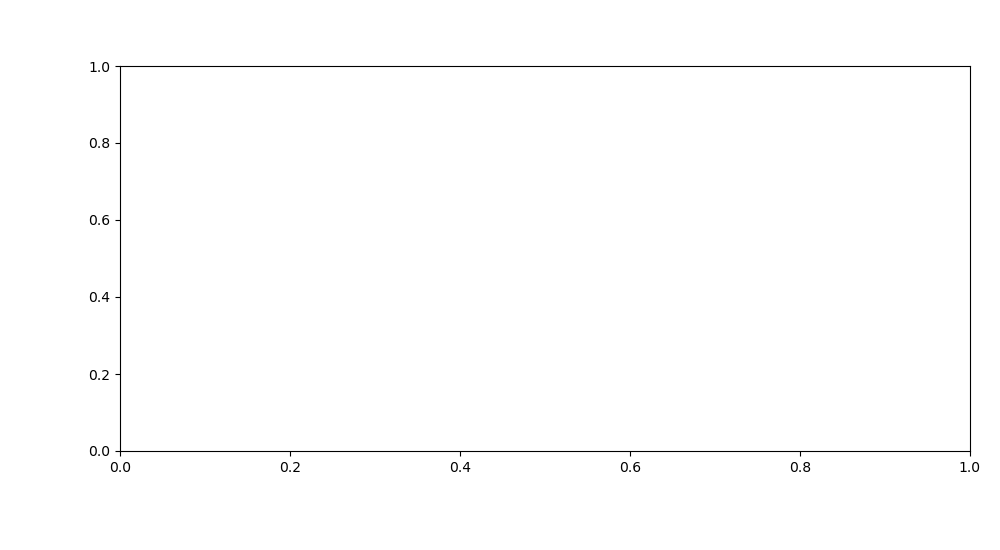

In [17]:
#Live plotting
fig_short, ax_short = plt.subplots(figsize=(10, 5.5))
_configure_live_figure(fig_short)

ani_short = FuncAnimation(
    fig_short,
    lambda _: update_site_shortfall_ax(ax_short, daily_meter),
    interval=2000,
    cache_frame_data=False
)

In [18]:
#SHUTDOWN GRAPH 3
if "ani_short" in globals():
    ani_short.event_source.stop()
print("Stopped shortfall plot animation. The shared site consumer remains active until Graph 2 shutdown is run.")

Stopped shortfall plot animation. The shared site consumer remains active until Graph 2 shutdown is run.


In [ ]:
# Optional diagnostics
# Use live state after the consumer has received records:
# diagnose_site_prediction_errors()
#
# Or inspect the current Parquet sink without waiting for the live consumer:
# diagnose_site_prediction_errors(source="parquet")